In [1]:
from scipy import special as sy
# for elliptical integrals of first kind (whatever that meeans)
import numpy as np
import matplotlib.pyplot as plt

I would like to explain how the math works in here.

I mean I don't know how the math works for most of this.

In [2]:
class point_bh:

    def __init__(self, M) -> None:
        self.M = M

    def A(self, r):
        return (1.0-2.0 * self.M/r)

    def B(self,r):
        return (self.A(r)**(-1))    
    
    def C(self,r):
        return (r**2)
    
    # compute u from rm
    def u(self, r):
        u = np.sqrt(self.C(r) / self.A(r))
        return (u)
    
    # functions concurrring to the deflectiona angle calculation
    def ss(self,r):
        return (np.sqrt((r-2.0*self.M)*(r+6.0*self.M)))
    
    def mm(self,r,s):
        return ((s-r+6.0*self.M)/2/s)
    
    def phif(self,r,s):
        return(np.arcsin(np.sqrt(2.0*s/(3.0*r-6.0*self.M+s))))
    
    # deflection angle
    def defAngle(self,r): 
        s=self.ss(r) 
        m=self.mm(r,s) 
        phi=self.phif(r,s)  
        F=sy.ellipkinc(phi, m) # using the ellipkinc function from scipy.special 
        return(-np.pi+4.0*np.sqrt(r/s)*F)


In [3]:
class point_mass:

    def __init__(self, M) -> None:
        self.M=M

    # classical formula
    def defAngle(self,u):
        return(4.0*self.M/u)

In [4]:
bh=point_bh(3.0)
pm=point_mass(3.0)

In [5]:
r = np.linspace(3/2, 10, 1000) * 2 * bh.M
u = bh.u(r)/2/bh.M

In [6]:
a = bh.defAngle(r)
b = pm.defAngle(u*2*bh.M)

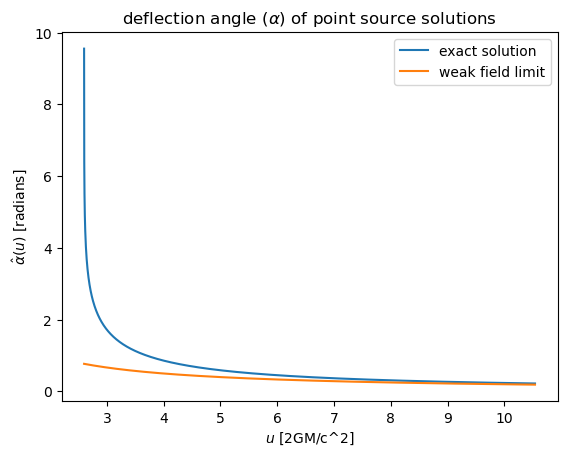

In [7]:
plt.plot(u,a,'-',label='exact solution')
plt.plot(u,b,'-',label='weak field limit')


plt.legend()
plt.title(r"deflection angle ($\alpha$) of point source solutions")

plt.xlabel(r"$u$ [2GM/c^2]")
plt.ylabel(r"$\hat\alpha(u)$ [radians]")

plt.savefig("deflection_angle_solutions.png")
plt.show()